# 01 · Problema, dataset y análisis exploratorio

**Proyecto integrador – Data Mining Tools (CC209) – TP1**

Este notebook cubre los puntos 1 a 4 del alcance del TP1: definición del problema, documentación del dataset, EDA y diagnóstico de calidad. La preparación, el split y los modelos están en `02_preparacion_y_modelos.ipynb`.

En cada sección separamos **lo que muestran los datos** (hechos verificables en la salida de la celda) de **nuestra interpretación** (lo que creemos que significa, y que podría estar equivocado).

## 1. Definición del problema

**Contexto.** Un banco portugués vende depósitos a plazo mediante campañas de llamadas telefónicas. Cada llamada cuesta tiempo de agente y también desgasta al cliente: en estos datos solo el 11.7 % de los contactos termina en una suscripción, es decir, casi 9 de cada 10 llamadas no venden.

**Necesidad.** El banco no puede (ni le conviene) llamar a todos con la misma prioridad. Necesita ordenar su lista de clientes para llamar primero a quienes tienen más probabilidad de aceptar.

| Elemento | Definición |
|---|---|
| Unidad de análisis | Un contacto de campaña: el último contacto registrado con un cliente dentro de una campaña. No es un cliente único (no hay identificador de cliente). |
| Pregunta principal | Con la información disponible **antes de llamar** (perfil del cliente, situación financiera e historial de campañas), ¿se puede ordenar a los clientes de modo que llamando solo al 20 % con mayor puntaje se alcance a la mayoría de los que suscribirían? |
| Tipo de problema | Clasificación binaria supervisada con clase positiva minoritaria, usada como modelo de *ranking* (lo que importa es el orden de las probabilidades). |
| Utilidad esperada | Una lista priorizada de clientes para el call center, que reduzca llamadas improductivas. |

**Criterios para considerar útil el resultado** (fijados antes de modelar):

1. Llamando al 20 % de clientes con mayor puntaje se capta **al menos el 50 %** de los suscriptores (lift ≥ 2.5 frente a llamar al azar).
2. El modelo supera a una **regla simple de negocio** (priorizar a quienes ya aceptaron en una campaña anterior), no solo a un clasificador trivial.
3. El modelo no usa ninguna variable que solo se conozca después de la llamada.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src import config, data

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 50)
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
AZUL, NARANJA = "#4C72B0", "#DD8452"


def guardar(nombre):
    plt.tight_layout()
    plt.savefig(config.FIGURES_DIR / f"{nombre}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 2. Dataset y procedencia

| | |
|---|---|
| Nombre | Bank Marketing (UCI Machine Learning Repository, id 222) |
| Fuente | https://archive.ics.uci.edu/dataset/222/bank+marketing — DOI [10.24432/C5K306](https://doi.org/10.24432/C5K306) |
| Autores | S. Moro, P. Rita y P. Cortez. Artículo asociado: *A data-driven approach to predict the success of bank telemarketing*, Decision Support Systems, 2014. |
| Versión usada | `bank-full` (la que entrega `fetch_ucirepo(id=222)`): 45 211 contactos, 16 variables de entrada y la variable objetivo. |
| Periodo | Mayo de 2008 a noviembre de 2010. El archivo viene ordenado por fecha, pero **no trae el año**: solo día y mes. |
| Licencia | Creative Commons Attribution 4.0 (CC BY 4.0): se puede usar y redistribuir citando a los autores. |

La descarga está en `src/data.py`. Se guarda una copia sin modificar en `data/raw/` para que el análisis no dependa de que UCI siga disponible.

In [2]:
raw = data.load_raw()
print(f"{raw.shape[0]:,} observaciones x {raw.shape[1]} columnas")
raw.head()

45,211 observaciones x 17 columnas


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


### Diccionario de variables

| Variable | Tipo | Descripción | ¿Se conoce antes de llamar? |
|---|---|---|---|
| `age` | numérica | Edad del cliente | Sí |
| `job` | categórica | Tipo de ocupación (11 categorías) | Sí |
| `marital` | categórica | Estado civil (`divorced` incluye viudos) | Sí |
| `education` | categórica | Nivel educativo: primary / secondary / tertiary | Sí |
| `default` | binaria | ¿Tiene un crédito en mora? | Sí |
| `balance` | numérica | Saldo promedio anual en euros | Sí |
| `housing` | binaria | ¿Tiene préstamo hipotecario? | Sí |
| `loan` | binaria | ¿Tiene préstamo personal? | Sí |
| `contact` | categórica | Medio de contacto: cellular / telephone | Sí |
| `day_of_week` | numérica | Día del último contacto. **Pese al nombre, toma valores de 1 a 31: es el día del mes.** | Sí (se planifica) |
| `month` | categórica | Mes del último contacto | Sí (se planifica) |
| `duration` | numérica | Duración de la última llamada en segundos | **No** |
| `campaign` | numérica | Número de contactos al cliente en esta campaña (incluye el último) | Sí |
| `pdays` | numérica | Días desde el último contacto de una campaña anterior; `-1` = nunca contactado | Sí |
| `previous` | numérica | Número de contactos en campañas anteriores | Sí |
| `poutcome` | categórica | Resultado de la campaña anterior: failure / other / success | Sí |
| `y` | binaria | **Objetivo:** ¿el cliente suscribió el depósito a plazo? | — |

**Por qué el dataset es adecuado.** Tiene 45 mil casos reales, mezcla variables numéricas y categóricas, trae problemas de calidad genuinos (faltantes, códigos centinela, valores extremos) y un desbalance de clases que obliga a pensar las métricas. Además plantea una decisión de modelado no trivial (`duration`), lo que da material para todo el flujo del curso.

**Limitaciones conocidas** (se verifican más abajo):
- Es un solo banco, en Portugal, durante la crisis financiera de 2008-2010. No hay base para generalizar a otro país o época.
- Esta versión no incluye indicadores macroeconómicos (la versión `bank-additional` sí).
- No hay identificador de cliente: un mismo cliente podría aparecer en más de una fila.
- Solo contiene clientes que el banco **decidió** llamar; no es una muestra de toda su cartera.

In [3]:
resumen = pd.DataFrame({
    "tipo": raw.dtypes.astype(str),
    "faltantes": raw.isna().sum(),
    "% faltantes": (raw.isna().mean() * 100).round(1),
    "valores únicos": raw.nunique(),
})
resumen

,tipo,faltantes,% faltantes,valores únicos
age,int64,0,0.0,77
job,str,288,0.6,11
marital,str,0,0.0,3
education,str,1857,4.1,3
default,str,0,0.0,2
balance,int64,0,0.0,7168
housing,str,0,0.0,2
loan,str,0,0.0,2
contact,str,13020,28.8,2
day_of_week,int64,0,0.0,31


In [4]:
raw.describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.9,10.6,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.3,3044.8,-8019.0,72.0,448.0,1428.0,102127.0
day_of_week,45211.0,15.8,8.3,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.2,257.5,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.8,3.1,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.2,100.1,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.6,2.3,0.0,0.0,0.0,0.0,275.0


## 3. Separación antes de explorar

Para que el EDA no nos lleve a tomar decisiones mirando datos que luego usaremos para evaluar, hacemos **primero** el split (60 % train / 20 % validation / 20 % test, estratificado) y todo lo que relaciona variables con `y` se analiza **solo en train**. El diagnóstico de calidad (faltantes, duplicados, rangos) sí se hace sobre el archivo completo porque no involucra a la variable objetivo. La justificación del split está en el notebook 02.

In [5]:
df = data.clean(raw)          # renombra day_of_week -> day, y -> 1/0, agrega `orden`
train, val, test = data.train_val_test_split(df)
tasa_global = train["y"].mean()
print(f"train={len(train):,}  val={len(val):,}  test={len(test):,}")
print(f"Tasa de suscripción en train: {tasa_global:.1%}")

train=27,126  val=9,042  test=9,043
Tasa de suscripción en train: 11.7%


## 4. EDA guiado por preguntas

### P1. ¿Qué tan frecuente es la suscripción?

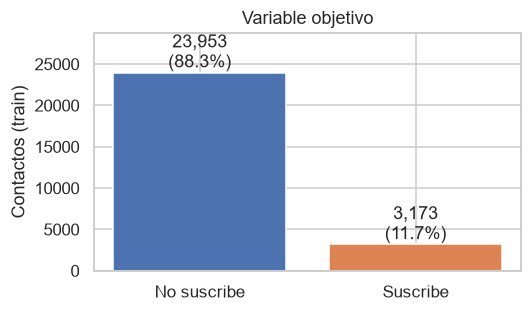

In [6]:
conteo = train["y"].map({0: "No suscribe", 1: "Suscribe"}).value_counts()
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(conteo.index, conteo.values, color=[AZUL, NARANJA])
for i, v in enumerate(conteo.values):
    ax.text(i, v, f"{v:,}\n({v / len(train):.1%})", ha="center", va="bottom")
ax.set_ylim(0, conteo.max() * 1.2)
ax.set_ylabel("Contactos (train)")
ax.set_title("Variable objetivo")
guardar("01_objetivo")

**Lo que muestran los datos.** En train, 11.7 % de los contactos termina en suscripción: aproximadamente 1 positivo por cada 7.5 negativos.

**Interpretación.** Con este desbalance, un modelo que diga siempre "no" acierta 88.3 % de las veces sin servir para nada. Por eso la *accuracy* queda descartada como métrica principal y usaremos métricas centradas en la clase positiva y en el ordenamiento (PR-AUC, captura en el top 20 %).

### P2. ¿Cómo se distribuyen las variables numéricas? ¿Hay valores extremos?

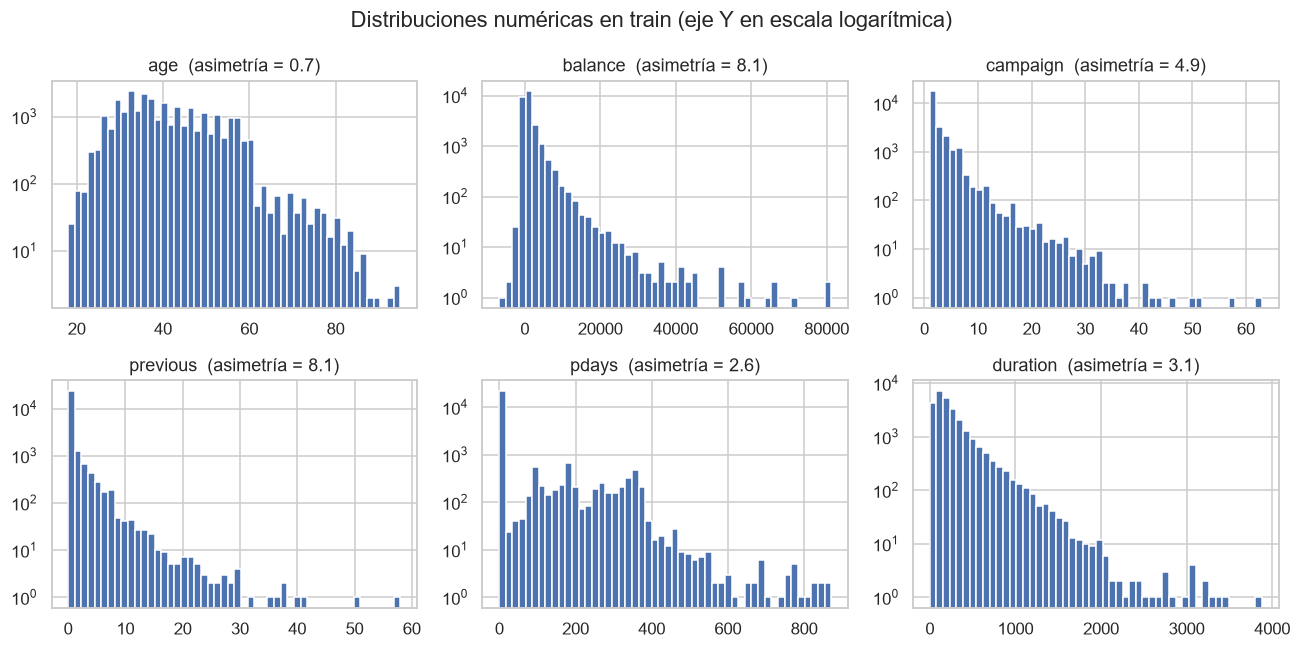

,0.01,0.50,0.95,0.99,1.00
age,23.0,39.0,59.00,71.00,95.0
balance,-627.0,454.0,5768.75,13146.25,81204.0
campaign,1.0,2.0,8.00,17.00,63.0
previous,0.0,0.0,3.00,9.00,58.0
pdays,-1.0,-1.0,319.00,370.00,871.0
duration,11.0,180.0,758.00,1272.00,3881.0


In [7]:
num_cols = ["age", "balance", "campaign", "previous", "pdays", "duration"]
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, col in zip(axes.ravel(), num_cols):
    ax.hist(train[col], bins=50, color=AZUL)
    ax.set_yscale("log")
    ax.set_title(f"{col}  (asimetría = {train[col].skew():.1f})")
fig.suptitle("Distribuciones numéricas en train (eje Y en escala logarítmica)")
guardar("02_numericas")

train[num_cols].quantile([0.01, 0.5, 0.95, 0.99, 1.0]).T

**Lo que muestran los datos.**
- `age` es la única variable razonablemente simétrica (mediana 39, rango 18-95).
- `balance` tiene saldos negativos (8.3 % de los clientes del archivo completo) y una cola derecha muy larga: la mediana en train es 454 € y en el archivo completo el máximo llega a 102 127 €.
- `campaign` y `previous` son conteos muy asimétricos: la mitad de los clientes recibió 1 o 2 llamadas, pero hay casos de más de 50. En el archivo completo `previous` tiene un valor de 275, cuando el siguiente más alto es 58.
- `pdays` concentra la gran mayoría de sus valores en `-1`.

**Interpretación.**
- Los saldos negativos son plausibles (sobregiros), no los tratamos como error.
- Los valores extremos de `balance` y `campaign` parecen clientes reales poco comunes, no errores de digitación; eliminarlos sería botar clientes que el banco sí tendría que puntuar en producción. Preferimos **comprimir la escala con logaritmo** en lugar de eliminar filas.
- El 275 en `previous` es sospechoso (posible error de registro), pero es una sola fila y no podemos confirmarlo; el logaritmo reduce su influencia sin tener que decidir si es un error.
- `pdays = -1` no es una cantidad: es un código. Tratarlo como número le diría a un modelo lineal que "nunca contactado" está pegado a "contactado ayer". Hay que separarlo.

### P3. ¿Qué perfil de cliente suscribe más?

La línea punteada marca la tasa global (11.7 %). Cada barra indica la tasa del grupo y cuántos contactos tiene, porque una tasa alta en un grupo pequeño es menos confiable.

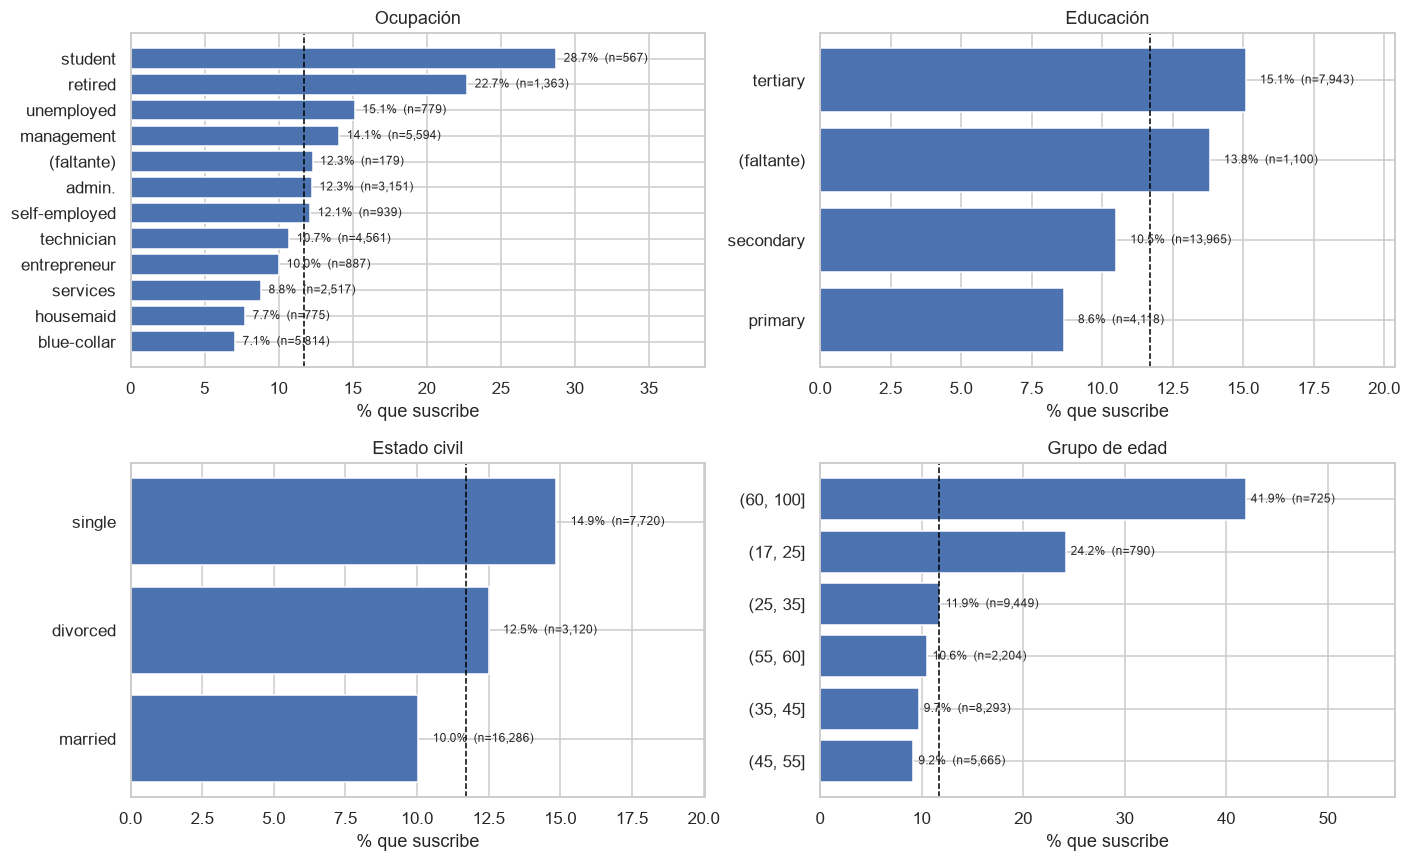

In [8]:
def tasa_por(col, ax, datos=train, titulo=None):
    g = (datos.assign(**{col: datos[col].astype("object").fillna("(faltante)")})
              .groupby(col, observed=True)["y"].agg(["size", "mean"]).sort_values("mean"))
    ax.barh(g.index.astype(str), g["mean"] * 100, color=AZUL)
    ax.axvline(tasa_global * 100, color="black", ls="--", lw=1)
    for i, (n, m) in enumerate(zip(g["size"], g["mean"])):
        ax.text(m * 100 + 0.5, i, f"{m:.1%}  (n={n:,})", va="center", fontsize=8)
    ax.set_xlim(0, g["mean"].max() * 100 * 1.35)
    ax.set_xlabel("% que suscribe")
    ax.set_title(titulo or col)
    return g


fig, axes = plt.subplots(2, 2, figsize=(13, 8))
tasa_por("job", axes[0, 0], titulo="Ocupación")
tasa_por("education", axes[0, 1], titulo="Educación")
tasa_por("marital", axes[1, 0], titulo="Estado civil")
edad = train.assign(grupo_edad=pd.cut(train["age"], [17, 25, 35, 45, 55, 60, 100]).astype(str))
tasa_por("grupo_edad", axes[1, 1], datos=edad, titulo="Grupo de edad")
guardar("03_perfil")

**Lo que muestran los datos.**
- Estudiantes (28.7 %) y jubilados (22.7 %) suscriben entre dos y tres veces más que el promedio; los obreros (`blue-collar`, 7.1 %) son el grupo más grande y el de menor tasa.
- Por edad la relación **no es lineal**: tiene forma de U. Los menores de 25 (24.2 %) y los mayores de 60 (41.9 %) suscriben mucho más que el grupo de 35 a 55 años (cerca de 9-10 %).
- La tasa sube con el nivel educativo: 8.6 % (primaria) → 15.1 % (terciaria).
- Los solteros (14.9 %) suscriben más que los casados (10.0 %).

**Interpretación.**
- Ocupación y edad cuentan en parte la misma historia (estudiante ≈ joven, jubilado ≈ mayor), así que sus efectos no son independientes.
- La forma de U en la edad anticipa que un modelo lineal con `age` como una sola variable no va a capturar el patrón; un modelo de árboles sí puede. Es una de las razones para comparar ambas familias.
- Los mayores de 60 son solo 725 contactos en train (2.7 %): la tasa es alta, pero el grupo pesa poco en el total.
- Hipótesis (no verificable con estos datos): jubilados y estudiantes tienen menos obligaciones de crédito y prefieren productos de ahorro de bajo riesgo.

### P4. ¿Influye la situación financiera del cliente?

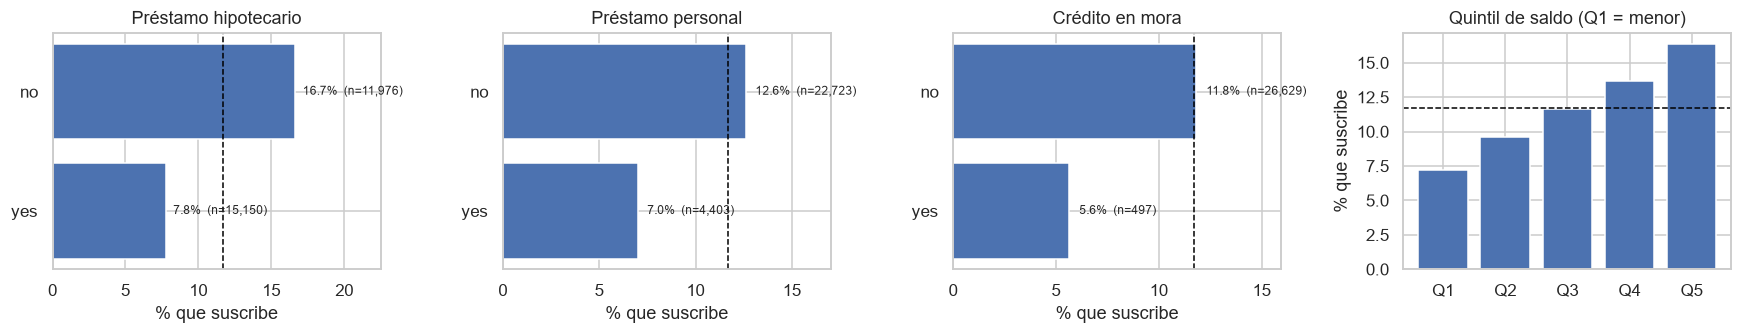

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))
tasa_por("housing", axes[0], titulo="Préstamo hipotecario")
tasa_por("loan", axes[1], titulo="Préstamo personal")
tasa_por("default", axes[2], titulo="Crédito en mora")
saldo = train.assign(quintil_saldo=pd.qcut(train["balance"], 5).astype(str))
g = saldo.groupby("quintil_saldo")["y"].mean().mul(100)
g = g.loc[sorted(g.index, key=lambda s: float(s.split(",")[0][1:]))]
axes[3].bar(range(5), g.values, color=AZUL)
axes[3].set_xticks(range(5), [f"Q{i}" for i in range(1, 6)])
axes[3].axhline(tasa_global * 100, color="black", ls="--", lw=1)
axes[3].set_title("Quintil de saldo (Q1 = menor)")
axes[3].set_ylabel("% que suscribe")
guardar("04_finanzas")

**Lo que muestran los datos.** Quienes no tienen hipoteca suscriben 16.7 % frente a 7.8 % de quienes sí la tienen. Algo similar ocurre con el préstamo personal (12.6 % vs 7.0 %). La tasa crece de forma ordenada con el saldo: 7.2 % en el quintil más bajo y 16.3 % en el más alto. Los clientes en mora son pocos (497 en train) y suscriben 5.6 %.

**Interpretación.** El patrón es coherente con el sentido común: un depósito a plazo inmoviliza dinero, y quien tiene deudas o poco saldo tiene menos excedente que inmovilizar. Ninguna de estas variables separa por sí sola (las tasas van de 7 % a 17 %), pero todas apuntan en la misma dirección. `default` tiene tan pocos casos positivos que probablemente aporte poco.

### P5. ¿Importa el historial de contacto con el banco?

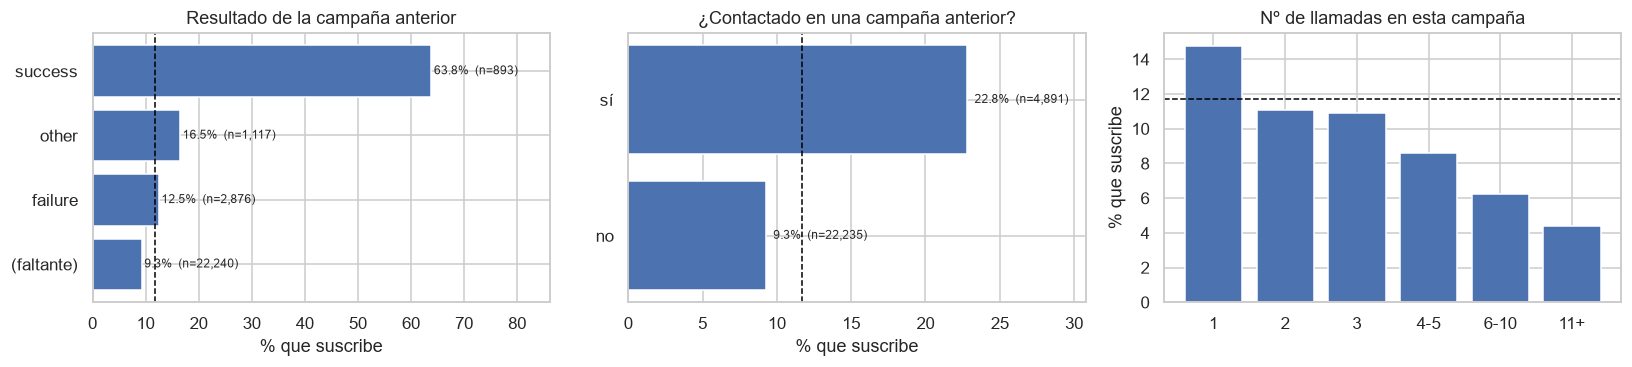

,size,mean
llamadas,,
1,10597,0.148
2,7475,0.111
3,3289,0.109
4-5,3181,0.086
6-10,1878,0.062
11+,706,0.044


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
tasa_por("poutcome", axes[0], titulo="Resultado de la campaña anterior")
hist = train.assign(contactado_antes=np.where(train["pdays"] == -1, "no", "sí"))
tasa_por("contactado_antes", axes[1], datos=hist, titulo="¿Contactado en una campaña anterior?")
camp = train.assign(llamadas=pd.cut(train["campaign"], [0, 1, 2, 3, 5, 10, 70],
                                    labels=["1", "2", "3", "4-5", "6-10", "11+"]))
g = camp.groupby("llamadas", observed=True)["y"].agg(["size", "mean"])
axes[2].bar(g.index.astype(str), g["mean"] * 100, color=AZUL)
axes[2].axhline(tasa_global * 100, color="black", ls="--", lw=1)
axes[2].set_title("Nº de llamadas en esta campaña")
axes[2].set_ylabel("% que suscribe")
guardar("05_historial")
g.assign(mean=g["mean"].round(3))

**Lo que muestran los datos.**
- Quien aceptó en la campaña anterior (`poutcome = success`) vuelve a aceptar 63.8 % de las veces. Es la señal más fuerte de todo el dataset, pero solo cubre 893 contactos de train (3.3 %).
- Haber sido contactado antes, sin importar el resultado, más que duplica la tasa (22.8 % vs 9.3 %).
- A más llamadas en la campaña actual, menor tasa: 14.8 % con una sola llamada, 4.4 % con más de diez.

**Interpretación.**
- `poutcome = success` justifica una **regla de negocio simple** que usaremos como baseline exigente: "llama primero a quienes ya aceptaron una vez".
- La caída con `campaign` **no demuestra** que insistir reduzca la probabilidad. Hay un sesgo de selección: quien acepta deja de recibir llamadas, de modo que los que acumulan muchas llamadas son justamente los que venían diciendo que no. Lo que sí se puede afirmar es que un cliente con muchas llamadas acumuladas es mal candidato.
- `poutcome` falta en 82 % de las filas, y eso coincide casi exactamente con `pdays = -1`: el faltante significa "no hubo campaña anterior", no un dato perdido.

### P6. ¿Importa cuándo se llama? ¿Cambian los datos en el tiempo?

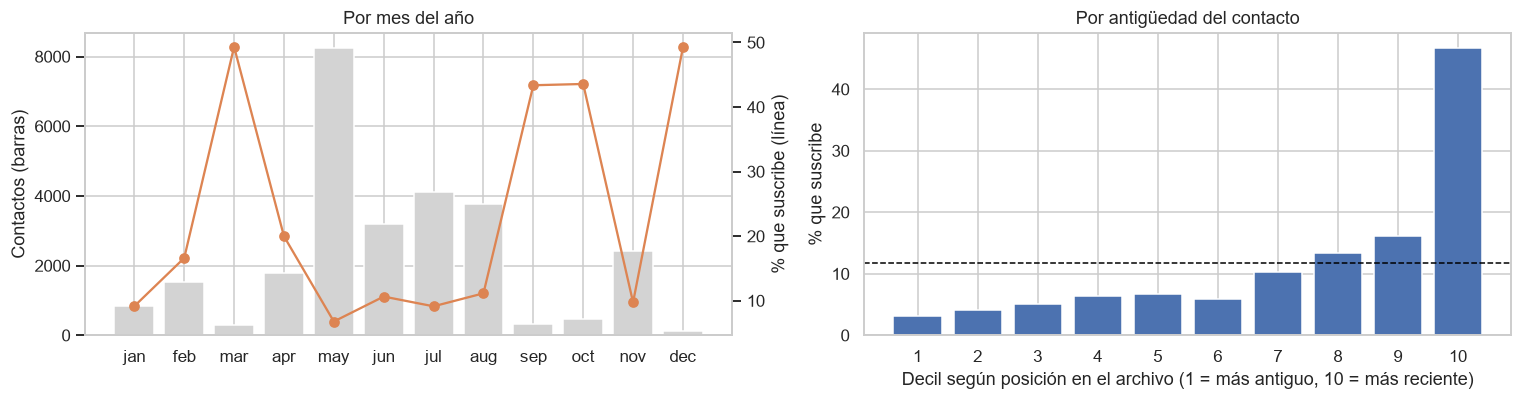

month,jan,feb,mar,apr,may,jun,jul,aug,sep,oct,nov,dec
size,831.000,1541.000,296.000,1787.0,8259.000,3206.000,4110.000,3762.000,332.000,459.000,2411.000,132.000
mean,0.091,0.166,0.493,0.2,0.068,0.106,0.091,0.111,0.434,0.436,0.097,0.492


In [11]:
mes = (train.groupby("month")["y"].agg(["size", "mean"])
            .reindex(config.MONTH_ORDER))
fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
ax = axes[0]
ax.bar(mes.index, mes["size"], color="lightgray")
ax.set_ylabel("Contactos (barras)")
ax2 = ax.twinx()
ax2.plot(mes.index, mes["mean"] * 100, color=NARANJA, marker="o")
ax2.set_ylabel("% que suscribe (línea)")
ax2.grid(False)
ax.set_title("Por mes del año")

decil = train.assign(decil=pd.cut(train["orden"], 10, labels=range(1, 11)))
d = decil.groupby("decil", observed=True)["y"].mean() * 100
axes[1].bar(d.index.astype(str), d.values, color=AZUL)
axes[1].axhline(tasa_global * 100, color="black", ls="--", lw=1)
axes[1].set_xlabel("Decil según posición en el archivo (1 = más antiguo, 10 = más reciente)")
axes[1].set_ylabel("% que suscribe")
axes[1].set_title("Por antigüedad del contacto")
guardar("06_tiempo")
mes.assign(mean=mes["mean"].round(3)).T

**Lo que muestran los datos.**
- Los meses con más llamadas tienen las tasas más bajas (mayo: 8 259 contactos, 6.8 %) y los meses con muy pocas llamadas tienen tasas altísimas (marzo, septiembre, octubre y diciembre: entre 43 % y 49 %, con 130 a 460 contactos cada uno).
- Como el archivo está ordenado por fecha, la posición de la fila sirve de reloj. La tasa de suscripción pasa de 3.1 % en el decil más antiguo a 46.8 % en el más reciente.

**Interpretación.**
- No creemos que marzo sea un mes "mágico". Lo más probable es que el banco haya **cambiado su forma de operar**: al inicio (2008) campañas masivas a muchos clientes, y hacia 2010 campañas pequeñas sobre clientes mejor seleccionados. `month` estaría actuando como etiqueta de *qué campaña fue* más que como estacionalidad.
- Consecuencia para el modelo: `month` va a aparecer como muy predictiva, pero esa relación puede no repetirse en una campaña futura. La dejamos en el TP1 y medimos en el notebook 02 cuánto depende el modelo de ella.
- Consecuencia para la evaluación: un split aleatorio mezcla periodos y puede dar una imagen optimista frente al uso real (entrenar con el pasado, puntuar el futuro). Lo cuantificamos en el notebook 02 con una prueba temporal.
- Esto es una hipótesis: el dataset no documenta la estrategia de cada campaña.

### P7. ¿Por qué no usar `duration`, si es la variable más relacionada con `y`?

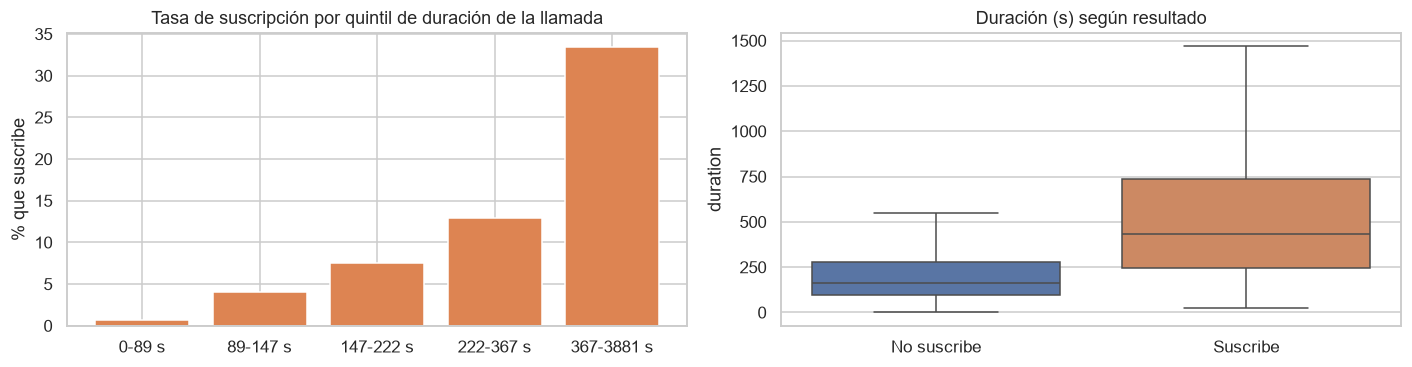

Llamadas con duración 0 en el archivo completo: 3 -> suscripciones: 0


In [12]:
dur = train.assign(quintil=pd.qcut(train["duration"], 5))
g = dur.groupby("quintil", observed=True)["y"].agg(["size", "mean"])
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
axes[0].bar([f"{int(i.left)}-{int(i.right)} s" for i in g.index], g["mean"] * 100, color=NARANJA)
axes[0].set_ylabel("% que suscribe")
axes[0].set_title("Tasa de suscripción por quintil de duración de la llamada")
sns.boxplot(data=train, x="y", y="duration", ax=axes[1], showfliers=False,
            hue="y", palette=[AZUL, NARANJA], legend=False)
axes[1].set_xticks([0, 1], ["No suscribe", "Suscribe"])
axes[1].set_xlabel("")
axes[1].set_title("Duración (s) según resultado")
guardar("07_duration")
print("Llamadas con duración 0 en el archivo completo:", (df["duration"] == 0).sum(),
      "-> suscripciones:", df.loc[df["duration"] == 0, "y"].sum())

**Lo que muestran los datos.** En el quintil de llamadas más cortas (hasta 89 s) suscribe 0.6 %; en el de llamadas más largas (más de 367 s), 33.4 %. La mediana de duración es 431 s cuando hay suscripción y 163 s cuando no.

**Interpretación.** La relación es real pero va en sentido contrario al que nos sirve: la llamada es larga **porque** el cliente está interesado y se están tomando sus datos. La duración se conoce recién cuando la llamada termina, y en ese momento ya se sabe el resultado. Usarla sería *data leakage*: el modelo se vería excelente en el notebook y sería inutilizable para decidir a quién llamar. Los propios autores del dataset advierten lo mismo. **Decisión: `duration` se excluye del modelo.** En el notebook 02 medimos cuánto inflaría las métricas.

### P8. ¿Las variables numéricas repiten información entre sí?

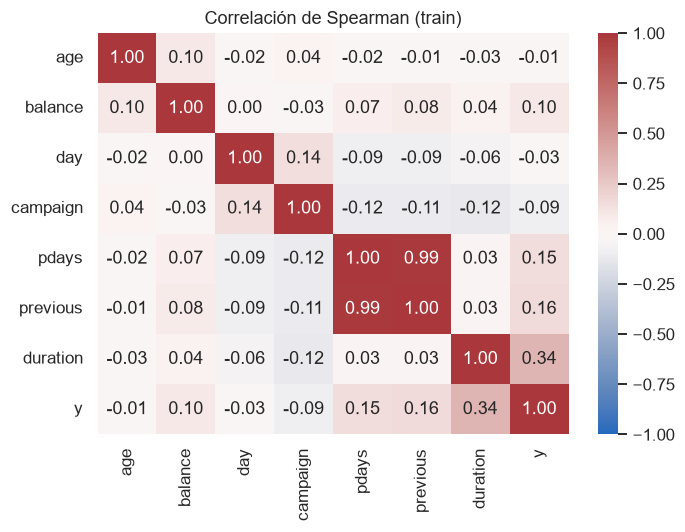

In [13]:
corr = train[["age", "balance", "day", "campaign", "pdays", "previous", "duration", "y"]].corr(method="spearman")
fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlación de Spearman (train)")
guardar("08_correlacion")

**Lo que muestran los datos.** `pdays` y `previous` tienen una correlación de Spearman cercana a 1. El resto de pares tiene correlaciones bajas. Fuera de `duration`, ninguna variable numérica supera por sí sola una correlación de 0.2 con `y`.

**Interpretación.** La correlación entre `pdays` y `previous` es casi un artefacto: ambas valen su mínimo exactamente en los mismos clientes (los nunca contactados), y eso domina el cálculo. Confirma que conviene extraer ese hecho en un indicador propio. Que las correlaciones individuales con `y` sean bajas no significa que las variables no sirvan: Spearman solo mide relaciones monótonas (no ve la U de la edad) y no considera combinaciones.

## 5. Diagnóstico de calidad de datos

Se hace sobre el archivo completo. Las decisiones que se derivan de aquí se implementan en `src/features.py` y se justifican en el notebook 02.

### 5.1 Valores faltantes

,faltantes,%
job,288,0.6
education,1857,4.1
contact,13020,28.8
poutcome,36959,81.7


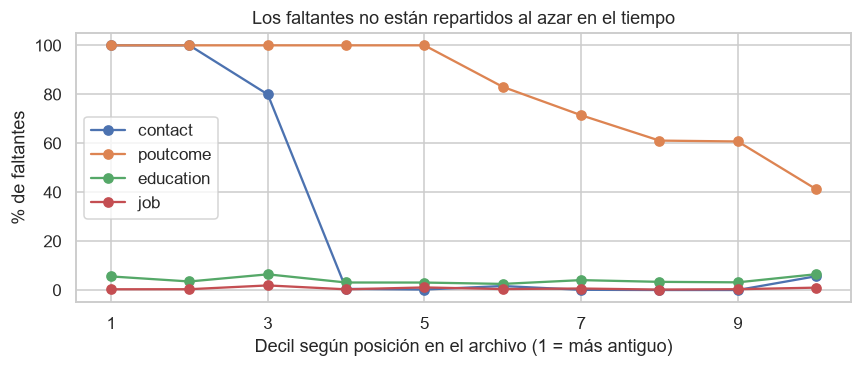

In [14]:
falt = raw.isna().sum()
falt = falt[falt > 0].to_frame("faltantes")
falt["%"] = (falt["faltantes"] / len(raw) * 100).round(1)
display(falt)

tmp = df.assign(decil=pd.cut(df["orden"], 10, labels=range(1, 11)))
por_decil = tmp.groupby("decil", observed=True)[["contact", "poutcome", "education", "job"]].agg(lambda s: s.isna().mean() * 100)
ax = por_decil.plot(marker="o", figsize=(8, 3.5))
ax.set_xlabel("Decil según posición en el archivo (1 = más antiguo)")
ax.set_ylabel("% de faltantes")
ax.set_title("Los faltantes no están repartidos al azar en el tiempo")
guardar("09_faltantes_tiempo")

**Lo que muestran los datos.** Cuatro variables tienen faltantes (en el archivo original aparecen como `unknown`; `ucimlrepo` los entrega como `NaN`): `poutcome` 81.7 %, `contact` 28.8 %, `education` 4.1 % y `job` 0.6 %. Los faltantes de `contact` se concentran casi por completo en los primeros deciles del archivo; los de `poutcome` bajan a medida que avanza el tiempo.

**Interpretación.**
- `poutcome` faltante = cliente sin campaña anterior. Es información, no ausencia de información.
- `contact` faltante parece un problema de registro del primer periodo (mayo-junio de 2008), no una característica del cliente. Por eso `contact = faltante` está asociado a una tasa de suscripción de 4.3 %: no porque el medio de contacto desconocido "cause" nada, sino porque marca el periodo de campañas masivas.
- En ambos casos imputar con la moda sería un error: borraría una señal y haría pasar a un cliente nunca contactado por uno con campaña fallida. **Decisión: conservar el faltante como categoría propia (`unknown`).**
- En `education` y `job` los faltantes son pocos y su tasa de suscripción (13.8 % y 12.3 %) es cercana al promedio. Se usa el mismo tratamiento por consistencia; el impacto es mínimo.

### 5.2 Duplicados, tipos, categorías y reglas lógicas

In [15]:
sin_orden = df.drop(columns="orden")
print("Filas duplicadas exactas:", sin_orden.duplicated().sum())
print("Filas duplicadas si se ignora duration:", sin_orden.drop(columns="duration").duplicated().sum())

print("\nRango de `day` (day_of_week en UCI):", df["day"].min(), "a", df["day"].max())

print("\nCategorías por variable:")
for col in ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "poutcome"]:
    print(f"  {col}: {sorted(raw[col].dropna().unique())}")

reglas = pd.Series({
    "age fuera de 18-100": (~df["age"].between(18, 100)).sum(),
    "campaign < 1 (debe incluir el último contacto)": (df["campaign"] < 1).sum(),
    "pdays = -1 pero previous > 0": ((df["pdays"] == -1) & (df["previous"] > 0)).sum(),
    "pdays >= 0 pero previous = 0": ((df["pdays"] >= 0) & (df["previous"] == 0)).sum(),
    "nunca contactado pero con poutcome informado": ((df["pdays"] == -1) & df["poutcome"].notna()).sum(),
    "contactado antes pero sin poutcome": ((df["pdays"] >= 0) & df["poutcome"].isna()).sum(),
    "duration = 0": (df["duration"] == 0).sum(),
    "previous > 100": (df["previous"] > 100).sum(),
}, name="filas que incumplen")
reglas.to_frame()

Filas duplicadas exactas: 0
Filas duplicadas si se ignora duration: 16

Rango de `day` (day_of_week en UCI): 1 a 31

Categorías por variable:
  job: ['admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed']
  marital: ['divorced', 'married', 'single']
  education: ['primary', 'secondary', 'tertiary']
  default: ['no', 'yes']
  housing: ['no', 'yes']
  loan: ['no', 'yes']
  contact: ['cellular', 'telephone']
  month: ['apr', 'aug', 'dec', 'feb', 'jan', 'jul', 'jun', 'mar', 'may', 'nov', 'oct', 'sep']
  poutcome: ['failure', 'other', 'success']


,filas que incumplen
age fuera de 18-100,0
campaign < 1 (debe incluir el último contacto),0
pdays = -1 pero previous > 0,0
pdays >= 0 pero previous = 0,0
nunca contactado pero con poutcome informado,0
contactado antes pero sin poutcome,5
duration = 0,3
previous > 100,1


**Lo que muestran los datos.**
- No hay filas duplicadas exactas. Si se ignora `duration` (que no usaremos) aparecen 16 filas repetidas.
- `day_of_week` va de 1 a 31, así que es el día del mes y no el día de la semana como indica la documentación de UCI.
- Las categorías están escritas de forma consistente (sin variantes de mayúsculas ni espacios).
- `pdays`, `previous` y `poutcome` son coherentes entre sí salvo en 5 filas, donde hubo contacto previo pero no se registró el resultado.
- Hay 3 llamadas de duración 0 y una fila con `previous = 275`.

**Interpretación y decisiones.**
- Las 16 filas repetidas sin `duration` las **conservamos**: sin identificador de cliente no podemos saber si son el mismo contacto registrado dos veces o dos clientes con el mismo perfil. Son 0.04 % del archivo.
- Renombramos `day_of_week` a `day`. Sin el año no podemos reconstruir el día de la semana real.
- Las 5 filas incoherentes quedan cubiertas por la categoría `unknown` de `poutcome`.
- Los tipos son correctos: las numéricas son enteras y las categóricas son texto. `default`, `housing` y `loan` son yes/no y se codifican como una sola columna binaria.

## 6. Resumen: qué nos llevamos al modelado

| Hallazgo del EDA | Decisión para el notebook 02 |
|---|---|
| 11.7 % de positivos | Split estratificado; métricas PR-AUC y captura en el top 20 %, no accuracy |
| `duration` solo se conoce después de llamar | Se excluye (leakage) |
| `poutcome = success` → 64 % de suscripción | Baseline con regla de negocio, además del Dummy |
| `pdays = -1` es un código | Indicador `contactado_antes` + `pdays` en 0 para esos casos |
| `balance`, `campaign`, `previous` muy asimétricas, con extremos plausibles | Transformación logarítmica en lugar de eliminar filas |
| Faltantes informativos y ligados al periodo | Categoría `unknown`, sin imputar la moda |
| Edad en forma de U | Comparar un modelo lineal con modelos de árboles |
| La tasa de suscripción cambia de 3 % a 47 % a lo largo del archivo | Prueba de sensibilidad temporal; `month` se marca como variable de riesgo |

**Lo que el EDA no permite concluir.** Todas las relaciones mostradas son asociaciones observadas en clientes que el banco eligió llamar. No sabemos cómo respondería un cliente que nunca fue seleccionado, ni podemos afirmar que cambiar una variable (por ejemplo, llamar en marzo) cambiaría el resultado.